# Лабораторная работа №1
## Разведочный анализ данных. Исследование и визуализация данных.

**Цель:** изучение различных методов визуализации данных.

**Датасет:** Wine (Вина) из библиотеки scikit-learn.

---

## 1. Описание набора данных

Датасет **Wine** содержит результаты химического анализа вин, произведённых тремя различными производителями в одном регионе Италии. Каждый образец описывается 13 числовыми признаками:

| № | Признак | Описание |
|---|---------|----------|
| 1 | Alcohol | Содержание алкоголя |
| 2 | Malic acid | Яблочная кислота |
| 3 | Ash | Зольность |
| 4 | Alcalinity of ash | Щёлочность золы |
| 5 | Magnesium | Магний |
| 6 | Total phenols | Общие фенолы |
| 7 | Flavanoids | Флавоноиды |
| 8 | Nonflavanoid phenols | Нефлавоноидные фенолы |
| 9 | Proanthocyanins | Проантоцианины |
| 10 | Color intensity | Интенсивность цвета |
| 11 | Hue | Оттенок |
| 12 | OD280/OD315 of diluted wines | OD280/OD315 разбавленных вин |
| 13 | Proline | Пролин |

Целевая переменная — класс вина (0, 1 или 2), определяющий производителя.
Датасет не содержит пропусков и включает 178 наблюдений.

## 2. Импорт библиотек и загрузка данных

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

import warnings
warnings.filterwarnings('ignore')

In [51]:
wine = load_wine()

df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['target_name'] = df['target'].map({i: name for i, name in enumerate(wine.target_names)})

df.head(10)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0,class_0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0,class_0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0,class_0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0,class_0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0,class_0


## 3. Основные характеристики датасета

### 3.1. Размерность и типы данных

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [53]:
df['target_name'].value_counts()

target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

### 3.2. Описательная статистика

In [54]:
df.describe().T.style.format("{:.2f}").background_gradient(cmap='YlOrRd', axis=1)

,count,mean,std,min,25%,50%,75%,max
alcohol,178.00,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,178.00,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,178.00,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,178.00,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,178.00,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,178.00,2.30,0.63,0.98,1.74,2.35,2.80,3.88
flavanoids,178.00,2.03,1.00,0.34,1.21,2.13,2.88,5.08
nonflavanoid_phenols,178.00,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,178.00,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,178.00,5.06,2.32,1.28,3.22,4.69,6.20,13.00


### 3.3. Проверка на пропуски и дубликаты

In [55]:
print("Пропуски:")
print(df.isnull().sum().sum())
print()
print(f"Дубликаты: {df.duplicated().sum()}")

Пропуски:
0

Дубликаты: 0


## 4. Визуальное исследование датасета

### 4.1. Распределение целевой переменной

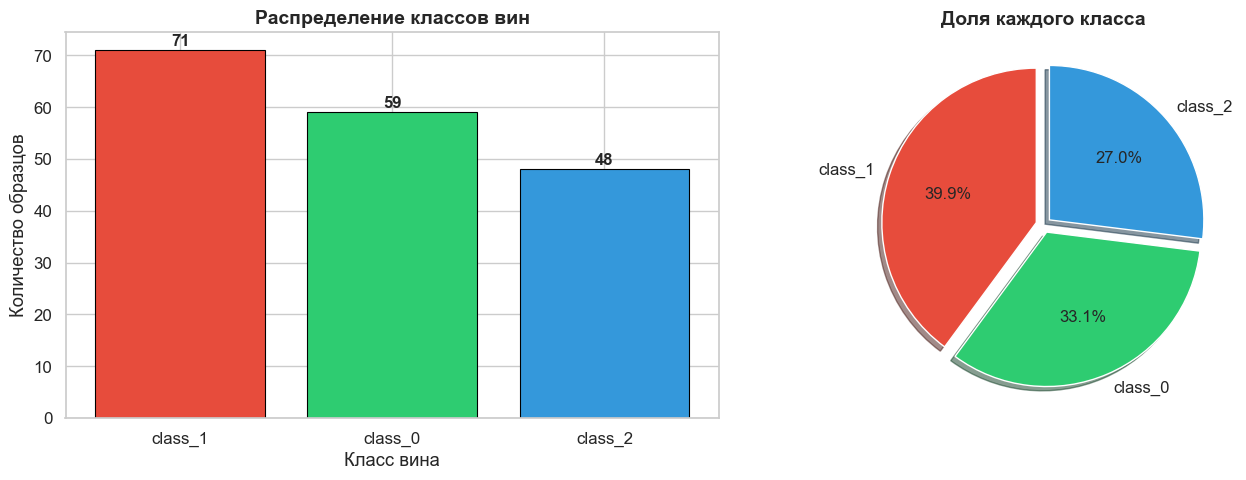

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#2ecc71', '#3498db']
counts = df['target_name'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Распределение классов вин', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Класс вина')
axes[0].set_ylabel('Количество образцов')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(counts.values, labels=counts.index, colors=colors, autopct='%1.1f%%',
            startangle=90, explode=(0.05, 0.05, 0.05), shadow=True,
            textprops={'fontsize': 12})
axes[1].set_title('Доля каждого класса', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.2. Гистограммы распределений признаков

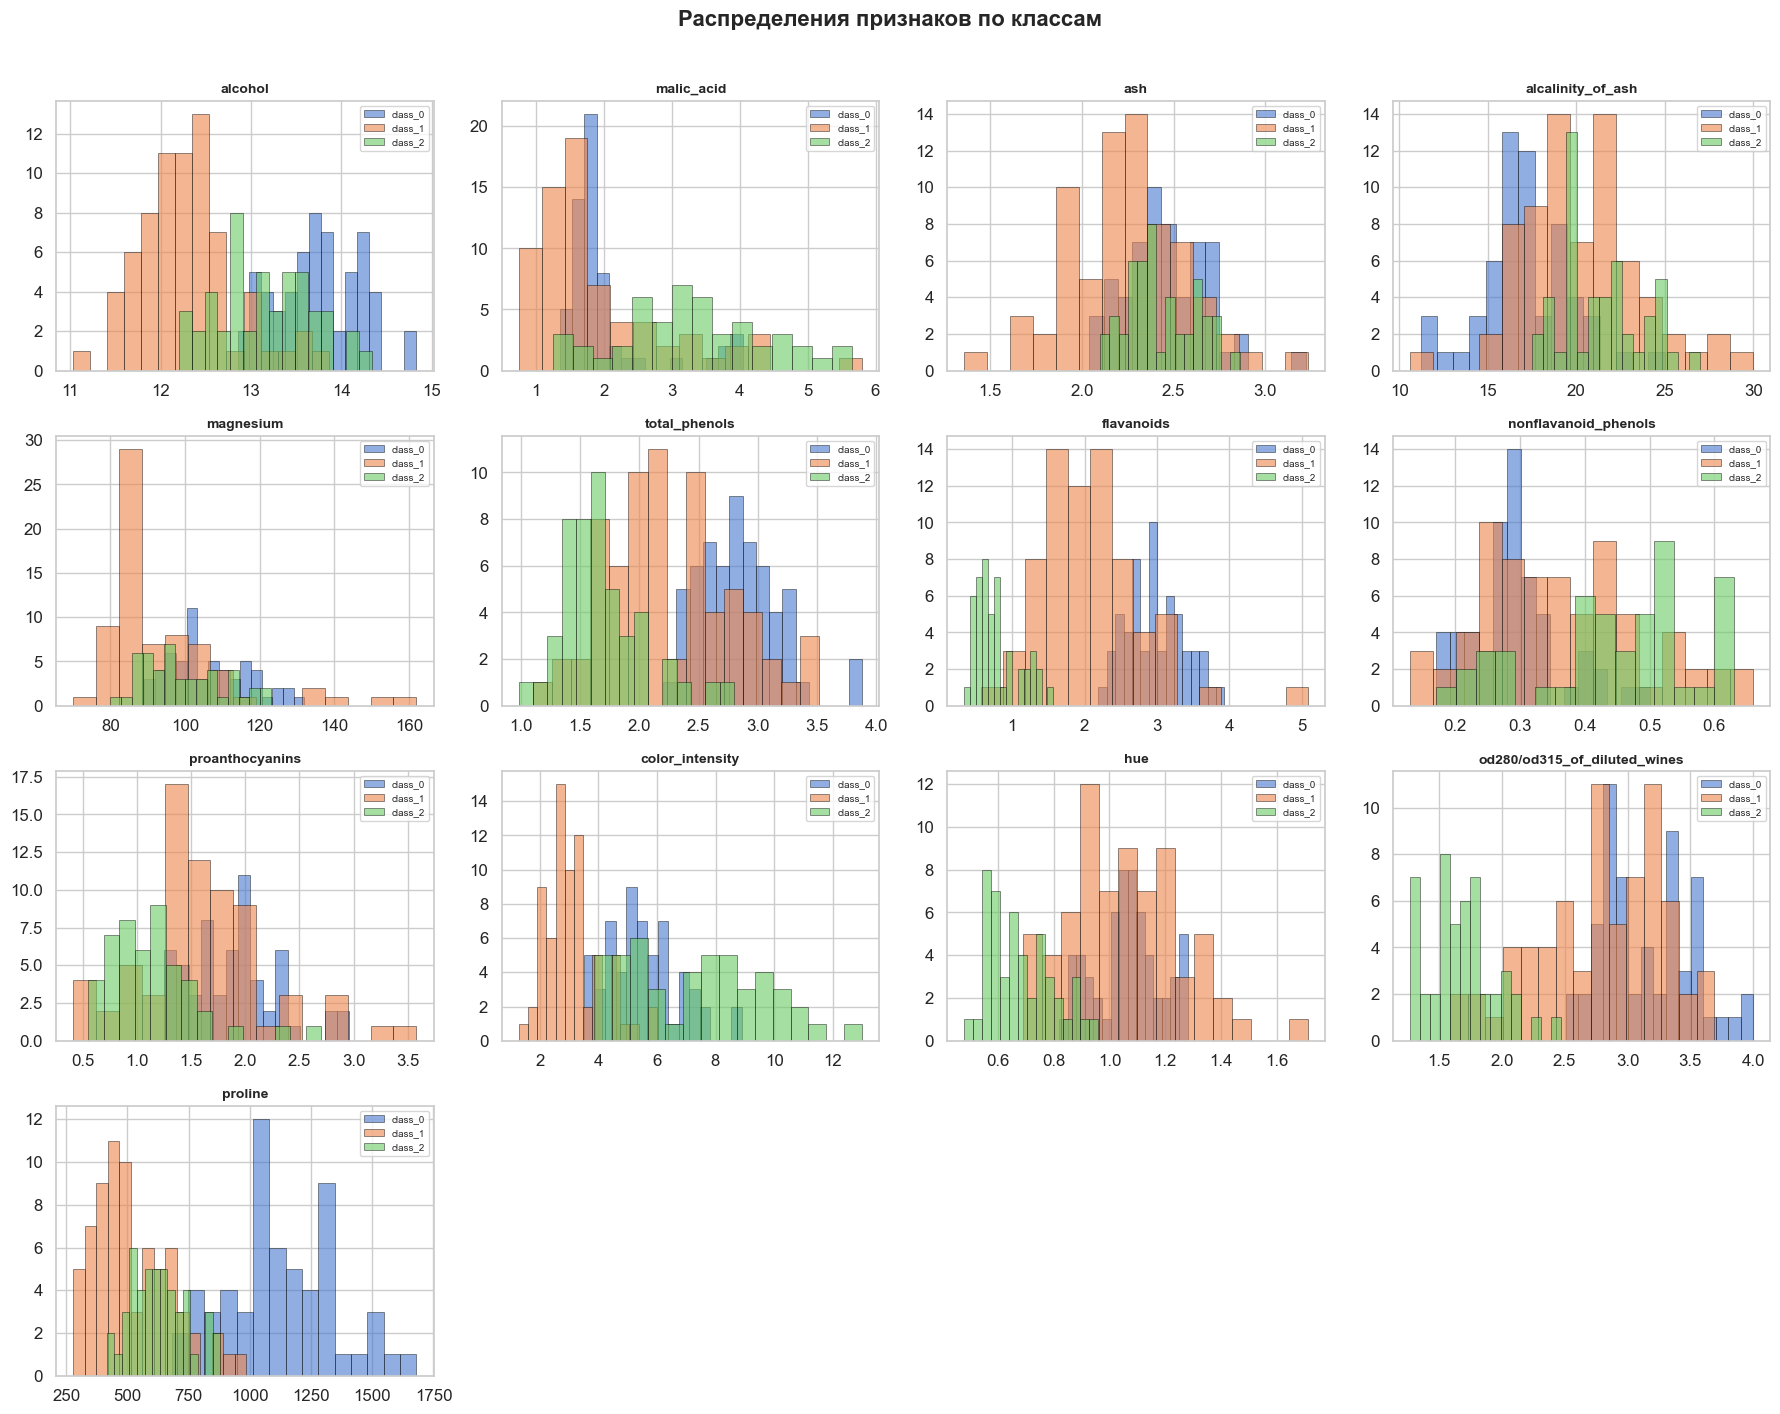

In [57]:
feature_cols = wine.feature_names

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    for cls in sorted(df['target'].unique()):
        subset = df[df['target'] == cls][col]
        ax.hist(subset, bins=15, alpha=0.6, label=wine.target_names[cls], edgecolor='black', linewidth=0.5)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Распределения признаков по классам', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.3. Ящики с усами (Box plots)

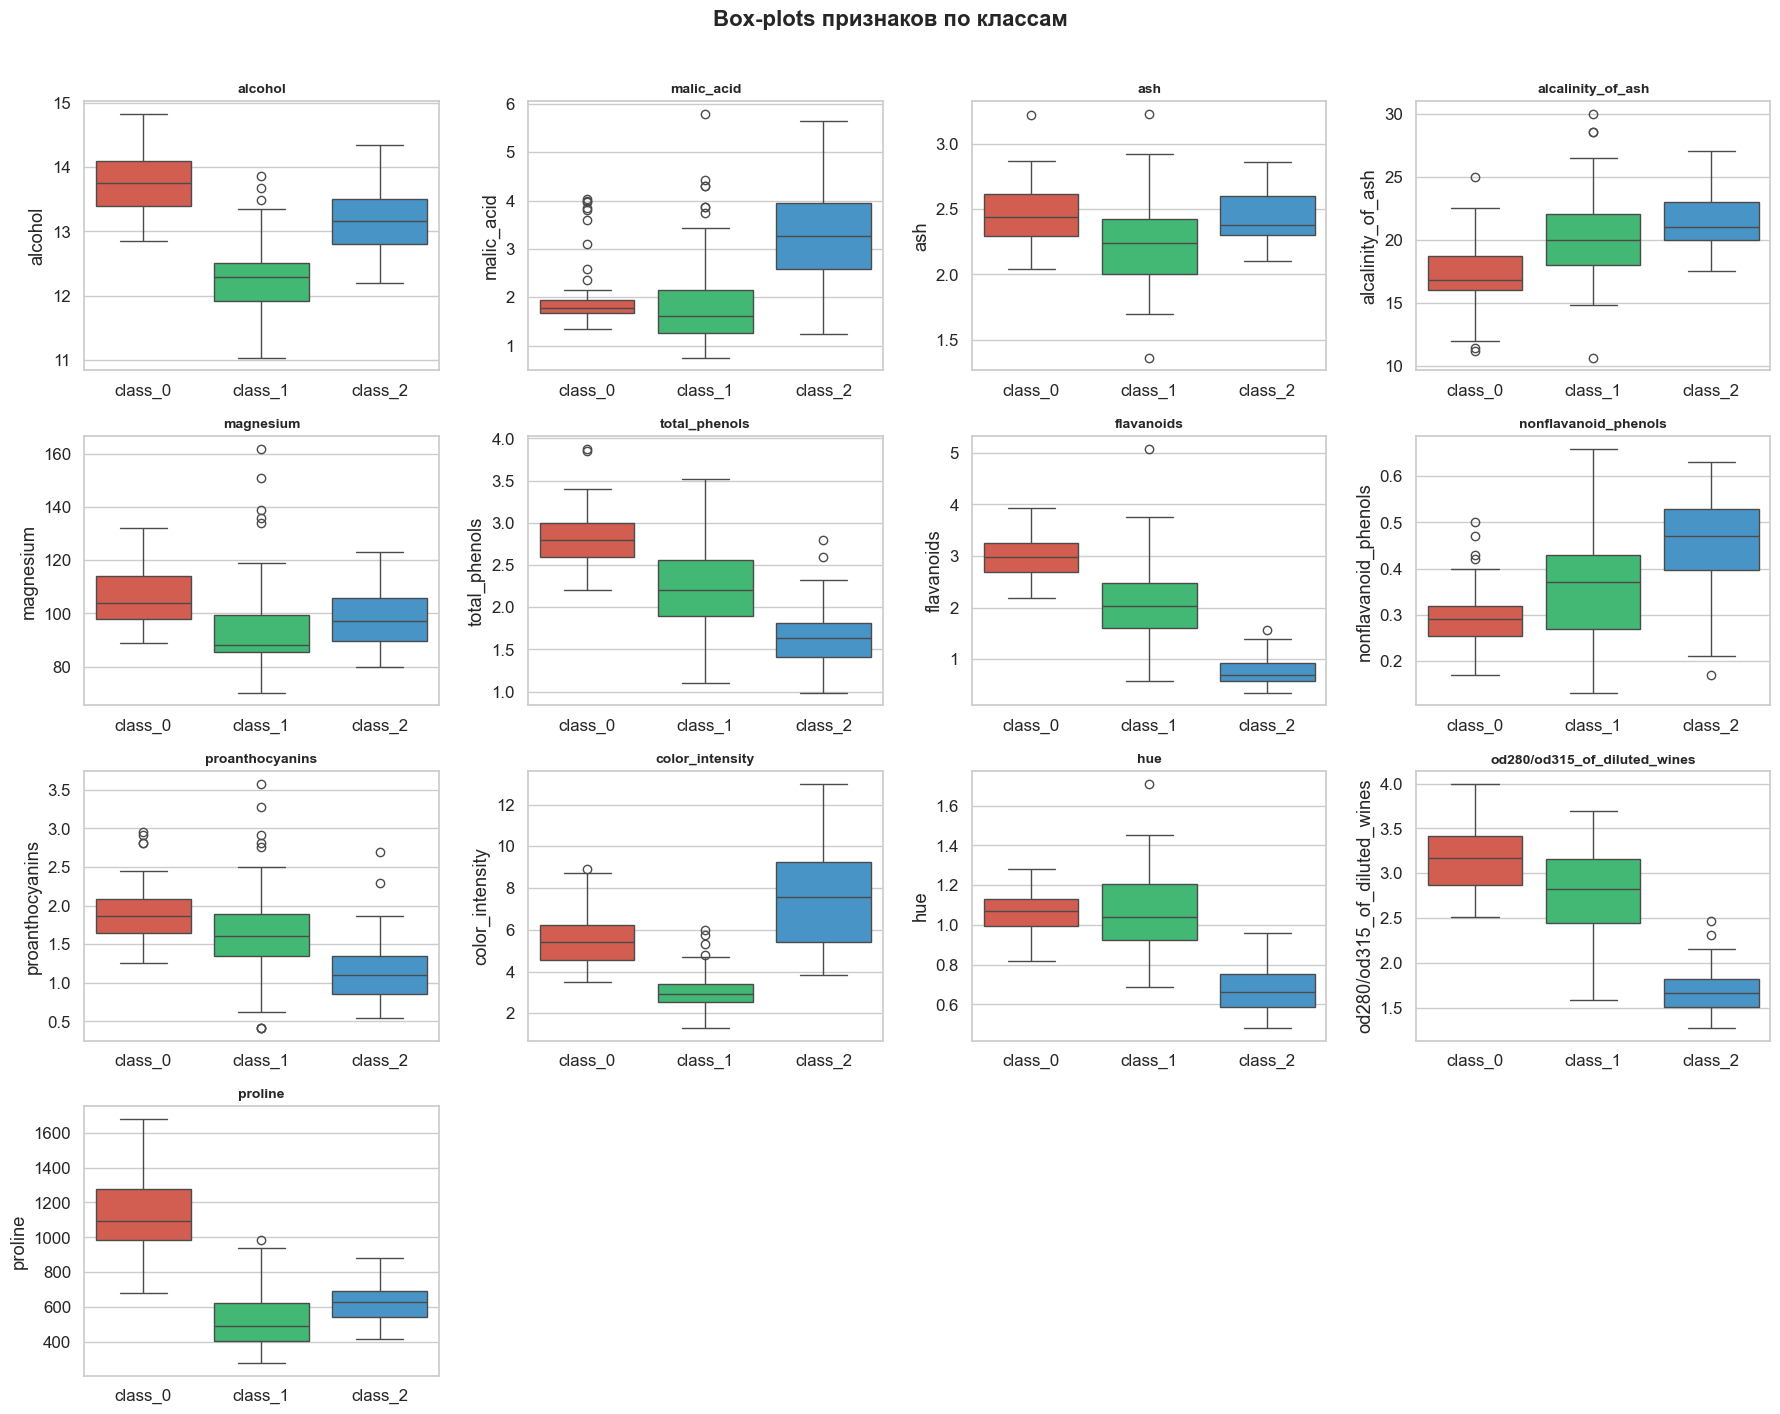

In [58]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    sns.boxplot(data=df, x='target_name', y=col, ax=ax, palette=colors, hue='target_name', legend=False)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Box-plots признаков по классам', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.4. Violin plots

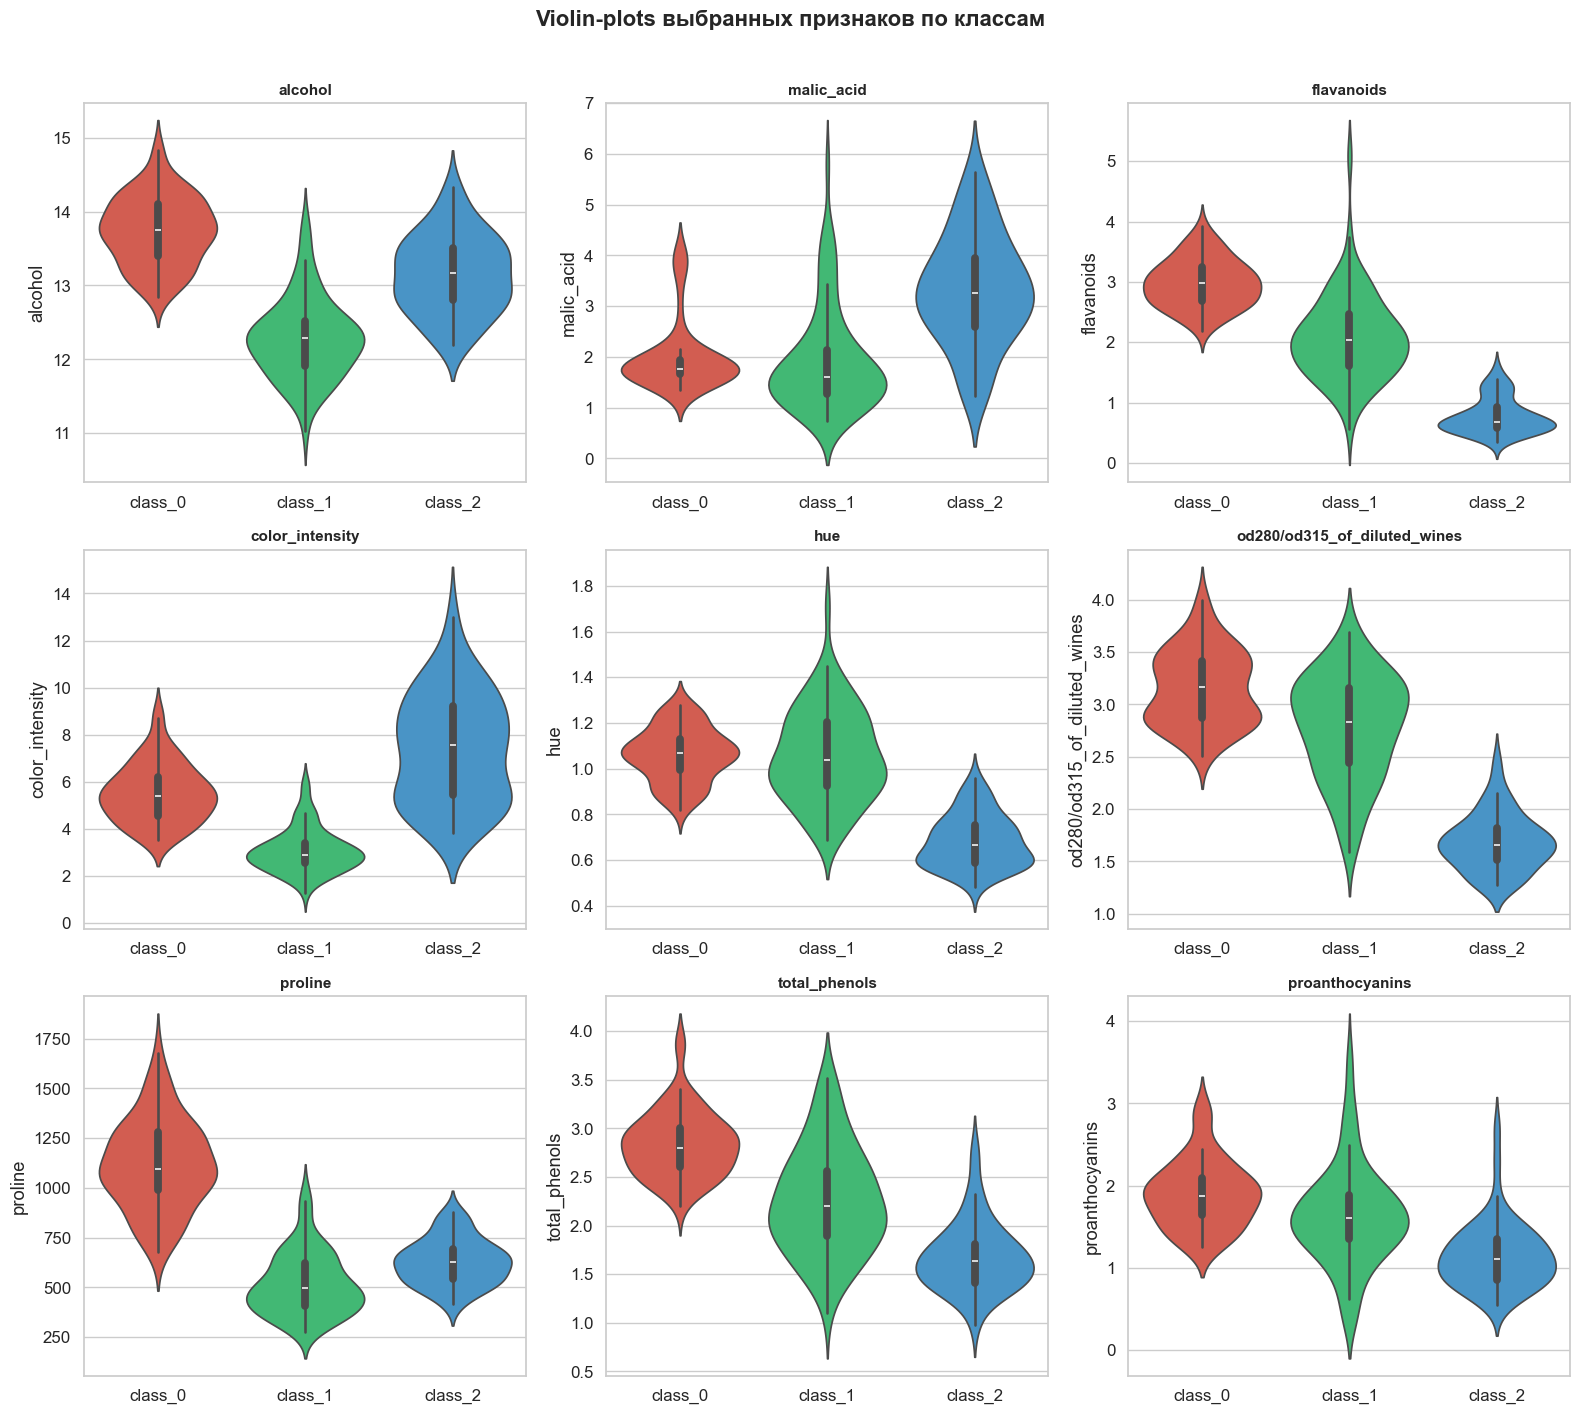

In [59]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

selected_features = ['alcohol', 'malic_acid', 'flavanoids', 'color_intensity',
                     'hue', 'od280/od315_of_diluted_wines', 'proline',
                     'total_phenols', 'proanthocyanins']

for i, col in enumerate(selected_features):
    ax = axes[i]
    sns.violinplot(data=df, x='target_name', y=col, ax=ax, palette=colors, hue='target_name', legend=False, inner='box')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

fig.suptitle('Violin-plots выбранных признаков по классам', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.5. Scatter plots (Диаграммы рассеяния)

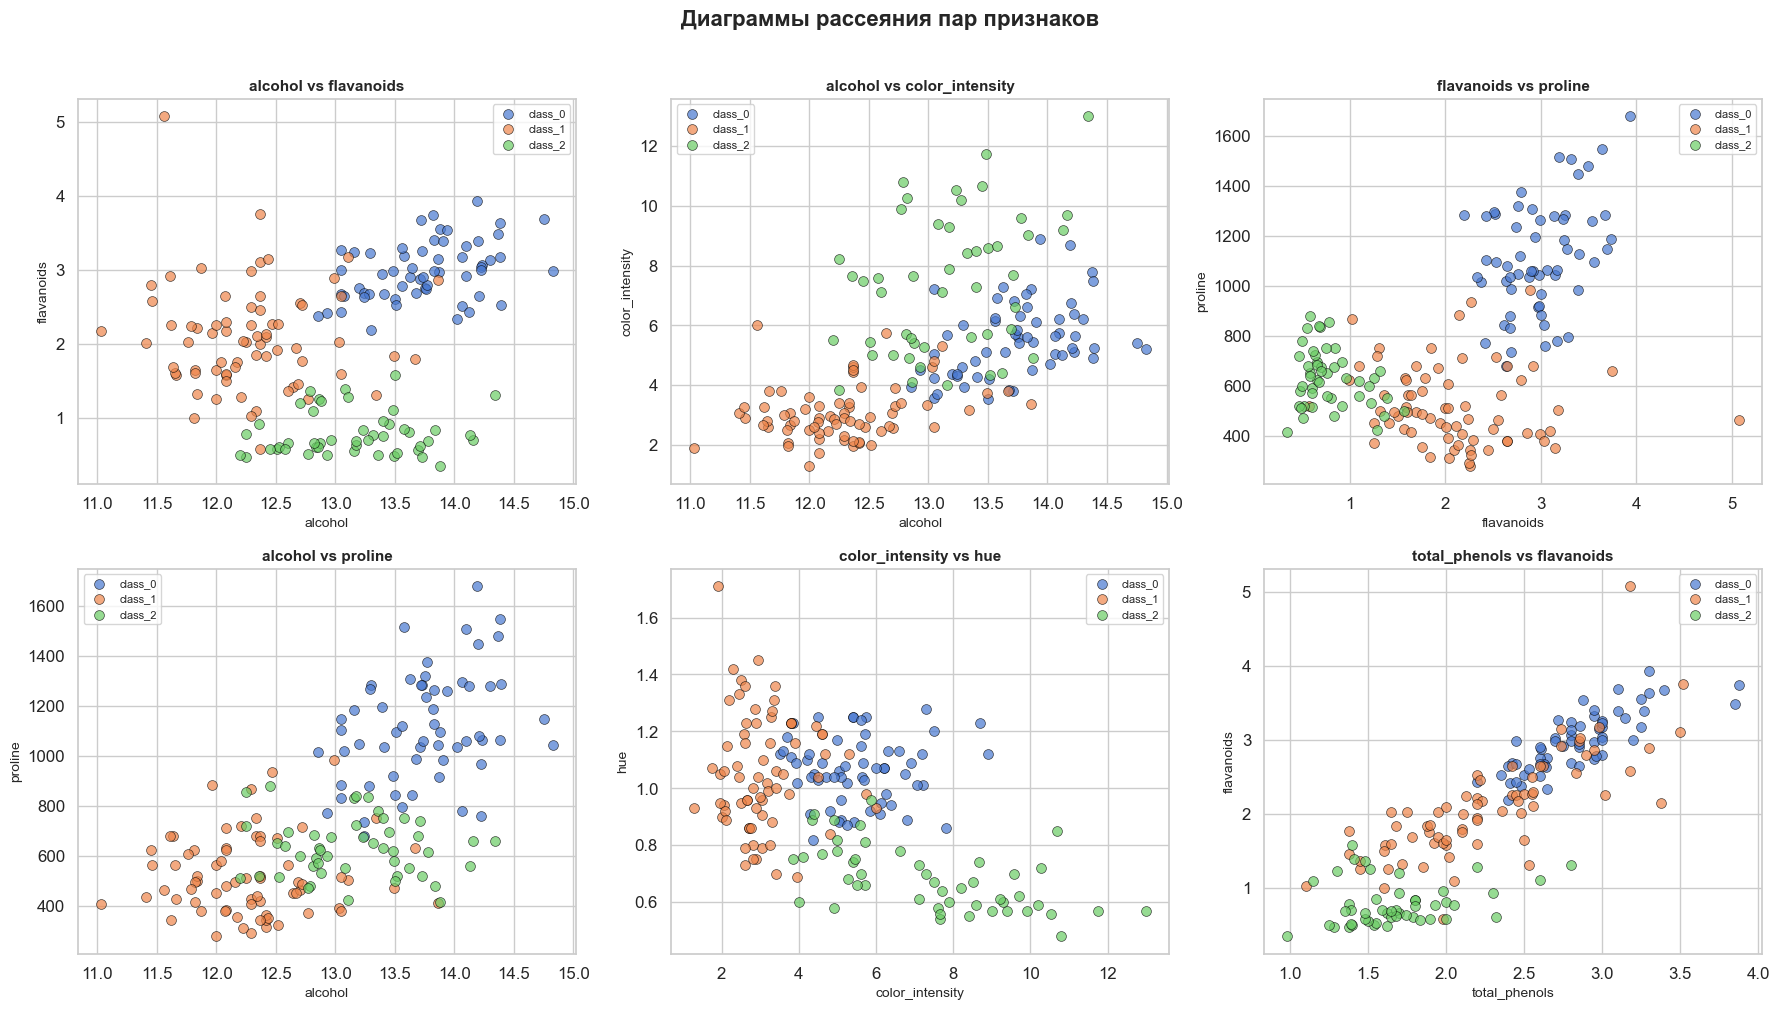

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

pairs = [
    ('alcohol', 'flavanoids'),
    ('alcohol', 'color_intensity'),
    ('flavanoids', 'proline'),
    ('alcohol', 'proline'),
    ('color_intensity', 'hue'),
    ('total_phenols', 'flavanoids'),
]

for i, (x, y) in enumerate(pairs):
    ax = axes[i]
    for cls in sorted(df['target'].unique()):
        subset = df[df['target'] == cls]
        ax.scatter(subset[x], subset[y], label=wine.target_names[cls],
                   alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
    ax.set_xlabel(x, fontsize=10)
    ax.set_ylabel(y, fontsize=10)
    ax.set_title(f'{x} vs {y}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Диаграммы рассеяния пар признаков', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.6. Pair plot (Матрица рассеяния)

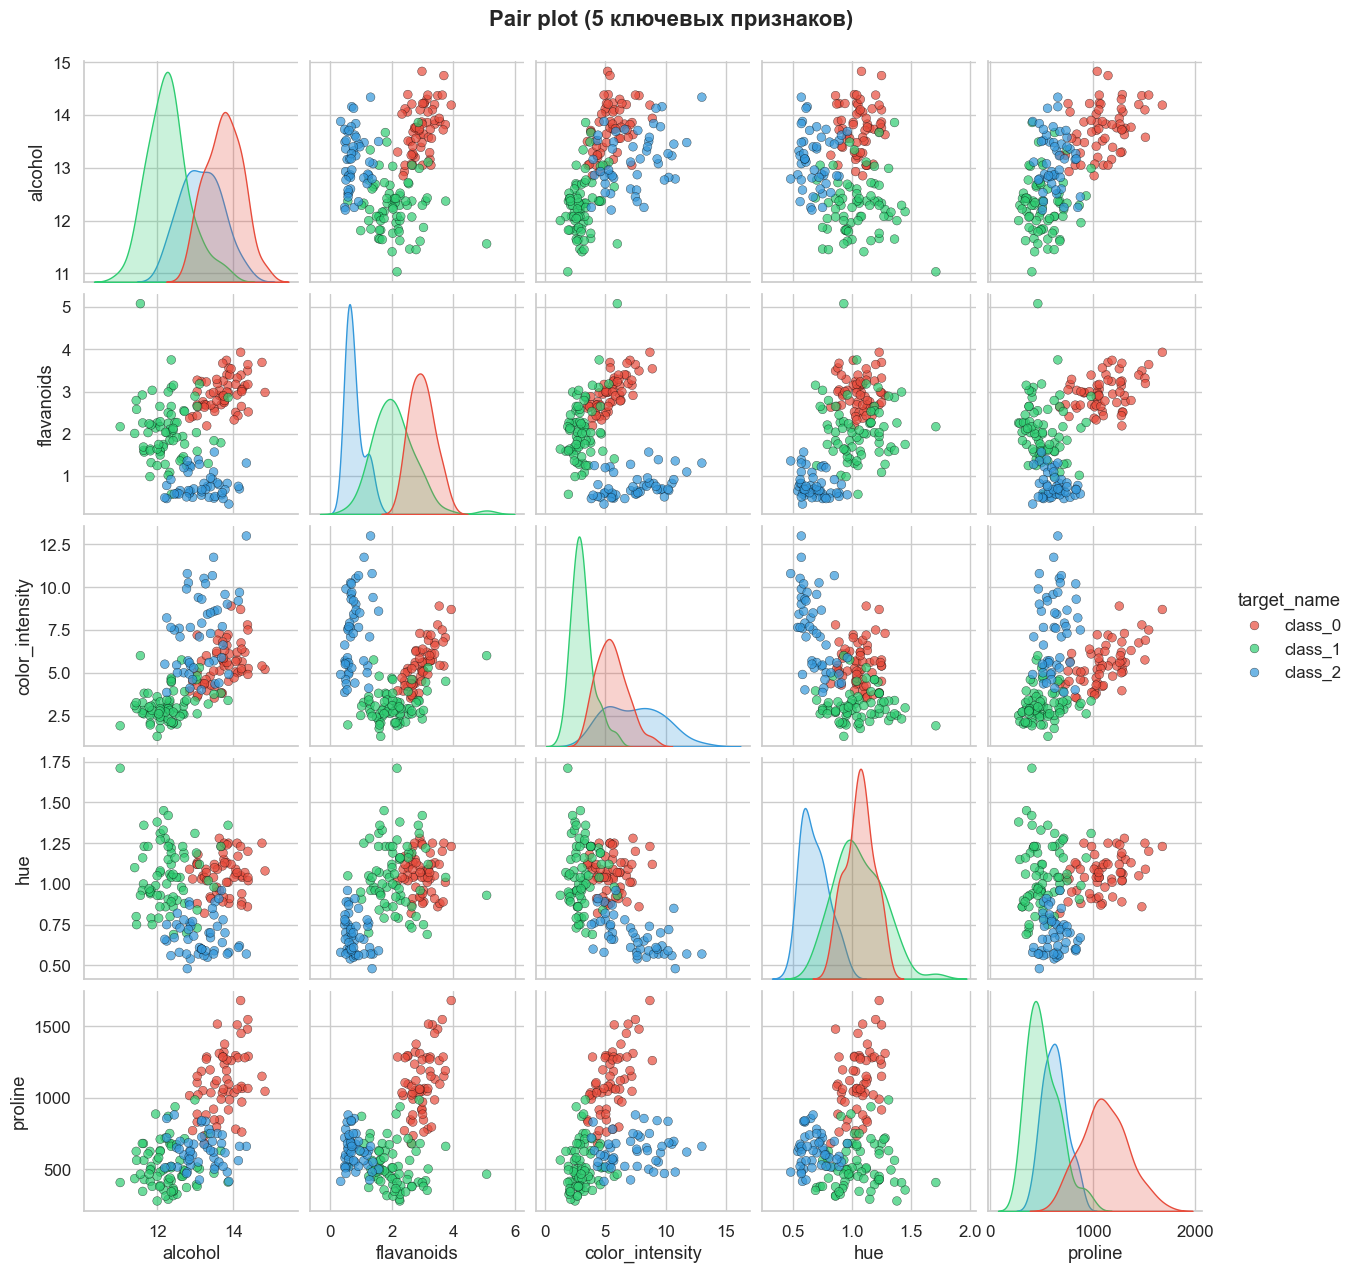

In [61]:
selected = ['alcohol', 'flavanoids', 'color_intensity', 'hue', 'proline', 'target_name']
g = sns.pairplot(df[selected], hue='target_name', palette=colors,
                 diag_kind='kde', plot_kws={'alpha': 0.7, 's': 40, 'edgecolor': 'black', 'linewidth': 0.3})
g.figure.suptitle('Pair plot (5 ключевых признаков)', fontsize=16, fontweight='bold', y=1.02)
plt.show()

## 5. Информация о корреляции признаков

### 5.1. Матрица корреляций (тепловая карта)

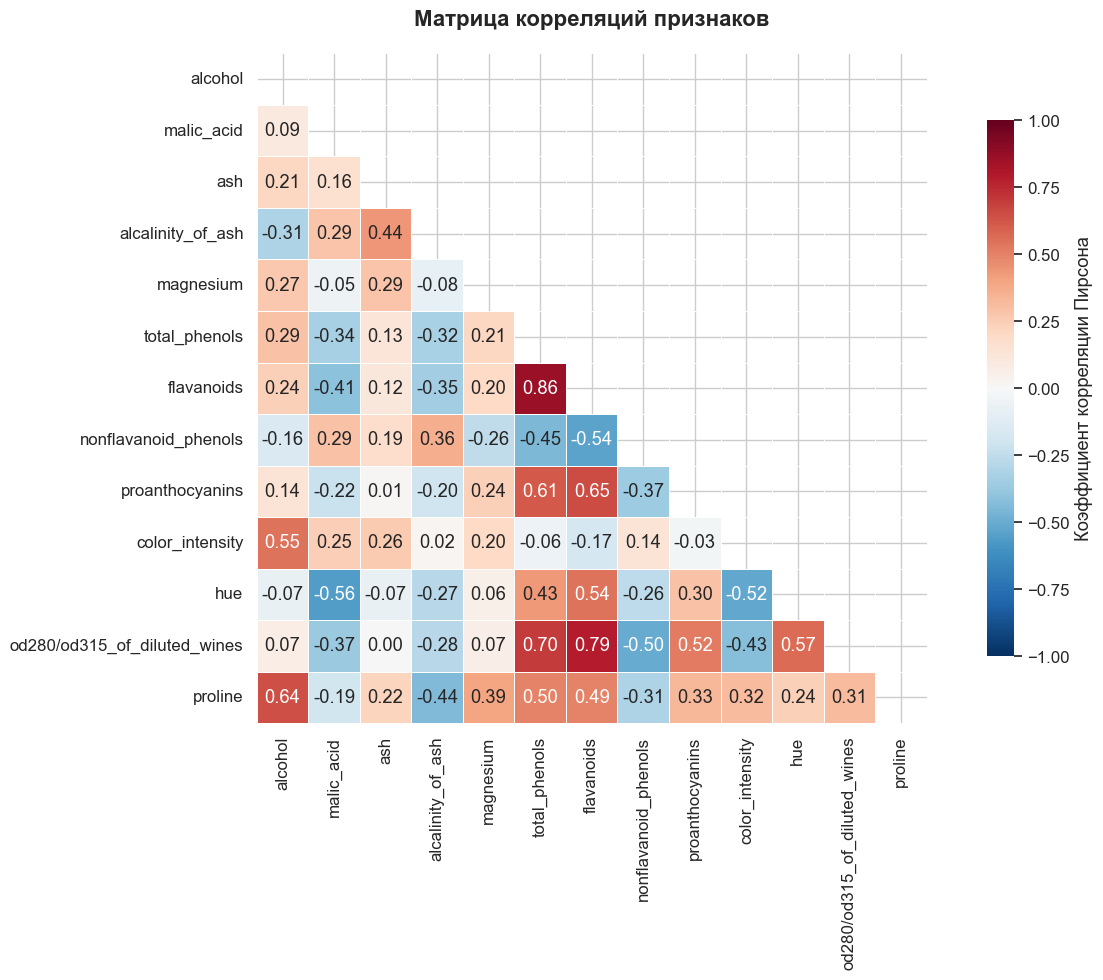

In [62]:
corr_matrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            square=True, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции Пирсона'})

ax.set_title('Матрица корреляций признаков', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 5.2. Топ коррелированных пар

In [63]:
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append({
            'Признак 1': corr_matrix.columns[i],
            'Признак 2': corr_matrix.columns[j],
            'Корреляция': corr_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs)
corr_df['|Корреляция|'] = corr_df['Корреляция'].abs()
corr_df = corr_df.sort_values('|Корреляция|', ascending=False)

corr_df.head(10).style.format({'Корреляция': '{:.3f}', '|Корреляция|': '{:.3f}'}).background_gradient(
    subset=['|Корреляция|'], cmap='YlOrRd')

,Признак 1,Признак 2,Корреляция,|Корреляция|
50,total_phenols,flavanoids,0.865,0.865
61,flavanoids,od280/od315_of_diluted_wines,0.787,0.787
55,total_phenols,od280/od315_of_diluted_wines,0.700,0.700
58,flavanoids,proanthocyanins,0.653,0.653
11,alcohol,proline,0.644,0.644
52,total_phenols,proanthocyanins,0.612,0.612
75,hue,od280/od315_of_diluted_wines,0.565,0.565
20,malic_acid,hue,-0.561,0.561
8,alcohol,color_intensity,0.546,0.546
60,flavanoids,hue,0.543,0.543


### 5.3. Корреляция признаков с целевой переменной

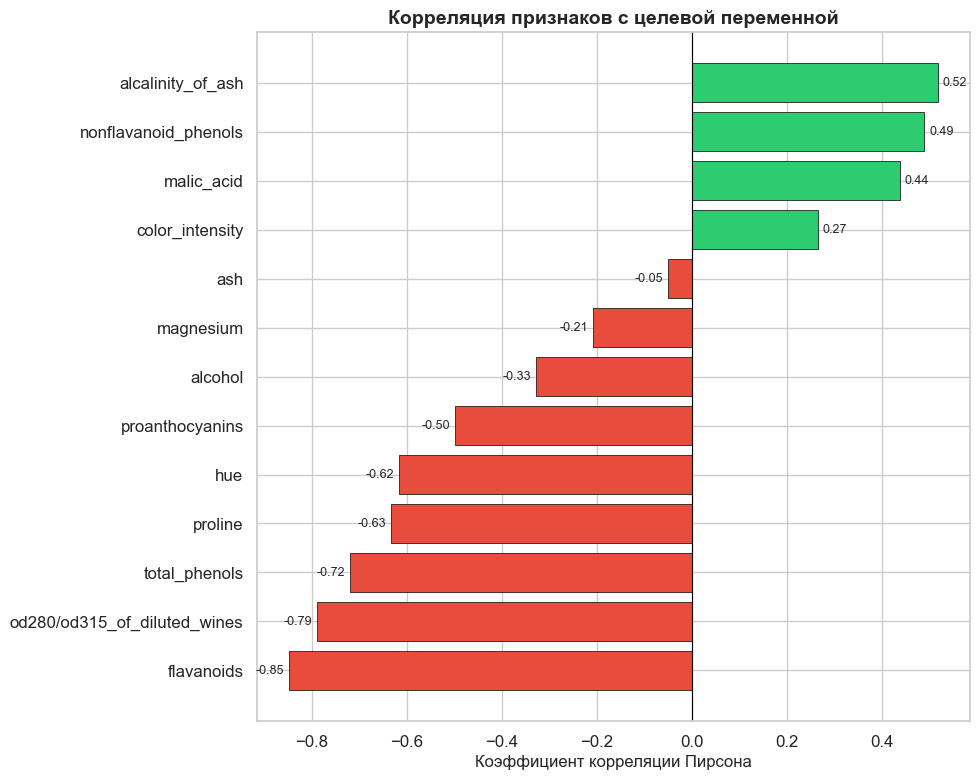

In [64]:
target_corr = df[feature_cols].corrwith(df['target']).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

colors_bar = ['#e74c3c' if v < 0 else '#2ecc71' for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Коэффициент корреляции Пирсона', fontsize=12)
ax.set_title('Корреляция признаков с целевой переменной', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

### 5.4. Scatter plots сильно коррелированных пар

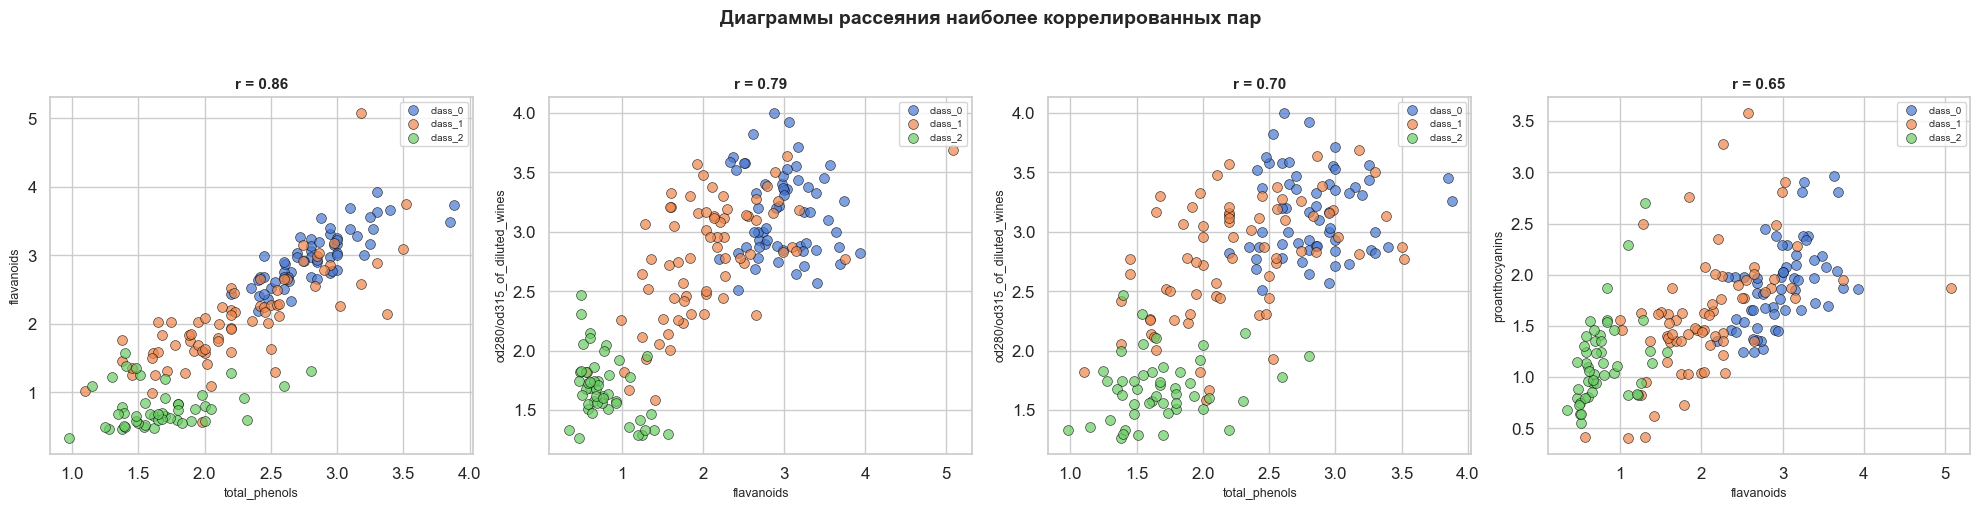

In [65]:
top_pairs = corr_df.head(4)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, (_, row) in enumerate(top_pairs.iterrows()):
    ax = axes[idx]
    feat1, feat2, corr = row['Признак 1'], row['Признак 2'], row['Корреляция']
    
    for cls in sorted(df['target'].unique()):
        subset = df[df['target'] == cls]
        ax.scatter(subset[feat1], subset[feat2], label=wine.target_names[cls],
                   alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel(feat1, fontsize=9)
    ax.set_ylabel(feat2, fontsize=9)
    ax.set_title(f'r = {corr:.2f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7)

fig.suptitle('Диаграммы рассеяния наиболее коррелированных пар', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Выводы

1. **Размер и качество данных:** Датасет Wine содержит 178 наблюдений и 13 числовых признаков. Пропуски и дубликаты отсутствуют.

2. **Распределение классов:** Три класса вин представлены относительно сбалансированно (59, 71 и 48 образцов).

3. **Распределение признаков:** Большинство признаков имеют различные распределения для разных классов, что говорит о их информативности для классификации.

4. **Корреляция:**
   - Сильная положительная корреляция наблюдается между `total_phenols` и `flavanoids`.
   - Сильная отрицательная корреляция — между `hue` и `color_intensity`.
   - Признаки `flavanoids`, `proline`, `color_intensity`, `alcohol` имеют наибольшую корреляцию с целевой переменной.

5. **Визуализация** позволяет визуально подтвердить разделимость классов по многим признакам, что является хорошим знаком для дальнейшей классификации.